## Load Saved Model

In [1]:
import tensorflow as tf

model=tf.keras.models.load_model("/kaggle/input/datasets/sourabhsaxena55/plant-model/plant_disease_efficientnet_finetuned.keras")

2026-03-02 03:46:47.703329: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772423207.890907      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772423207.941865      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772423208.390114      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772423208.390155      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772423208.390158      55 computation_placer.cc:177] computation placer alr

## Test Dataset

In [2]:
import os
from tensorflow.keras.applications.efficientnet import preprocess_input

data_dir="/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color"

IMG_SIZE=224
BATCH_SIZE=32
SEED=42

train_ds=tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE
)

temp_ds=tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE
)

temp_batches=tf.data.experimental.cardinality(temp_ds)
val_size=temp_batches // 2
val_ds=temp_ds.take(val_size)
test_ds=temp_ds.skip(val_size)

test_ds=test_ds.map(lambda x,y:(preprocess_input(x),y))

Found 54305 files belonging to 38 classes.
Using 38014 files for training.
Found 54305 files belonging to 38 classes.
Using 16291 files for validation.


## Generate Predictions

In [3]:
import numpy as np
from sklearn.metrics import classification_report,confusion_matrix

y_true=[]
y_pred=[]

for images, labels in test_ds:
    preds=model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_preds=np.array(y_true)
y_pred=np.array(y_pred)

I0000 00:00:1772423304.522706     120 service.cc:152] XLA service 0x7e6450249260 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772423304.522748     120 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1772423305.406396     120 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1772423311.656797     120 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━

## Classification Report

In [5]:
print(classification_report(y_true,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.92      0.95        92
           1       1.00      1.00      1.00        99
           2       1.00      1.00      1.00        40
           3       0.97      1.00      0.98       247
           4       1.00      1.00      1.00       216
           5       1.00      0.99      0.99       183
           6       0.99      1.00      1.00       133
           7       0.88      0.86      0.87        85
           8       1.00      1.00      1.00       162
           9       0.92      0.93      0.92       140
          10       1.00      1.00      1.00       167
          11       0.99      1.00      0.99       206
          12       0.99      0.99      0.99       197
          13       1.00      1.00      1.00       169
          14       1.00      1.00      1.00        64
          15       1.00      1.00      1.00       819
          16       1.00      1.00      1.00       340
          17       0.99    

## Confusion Matrix

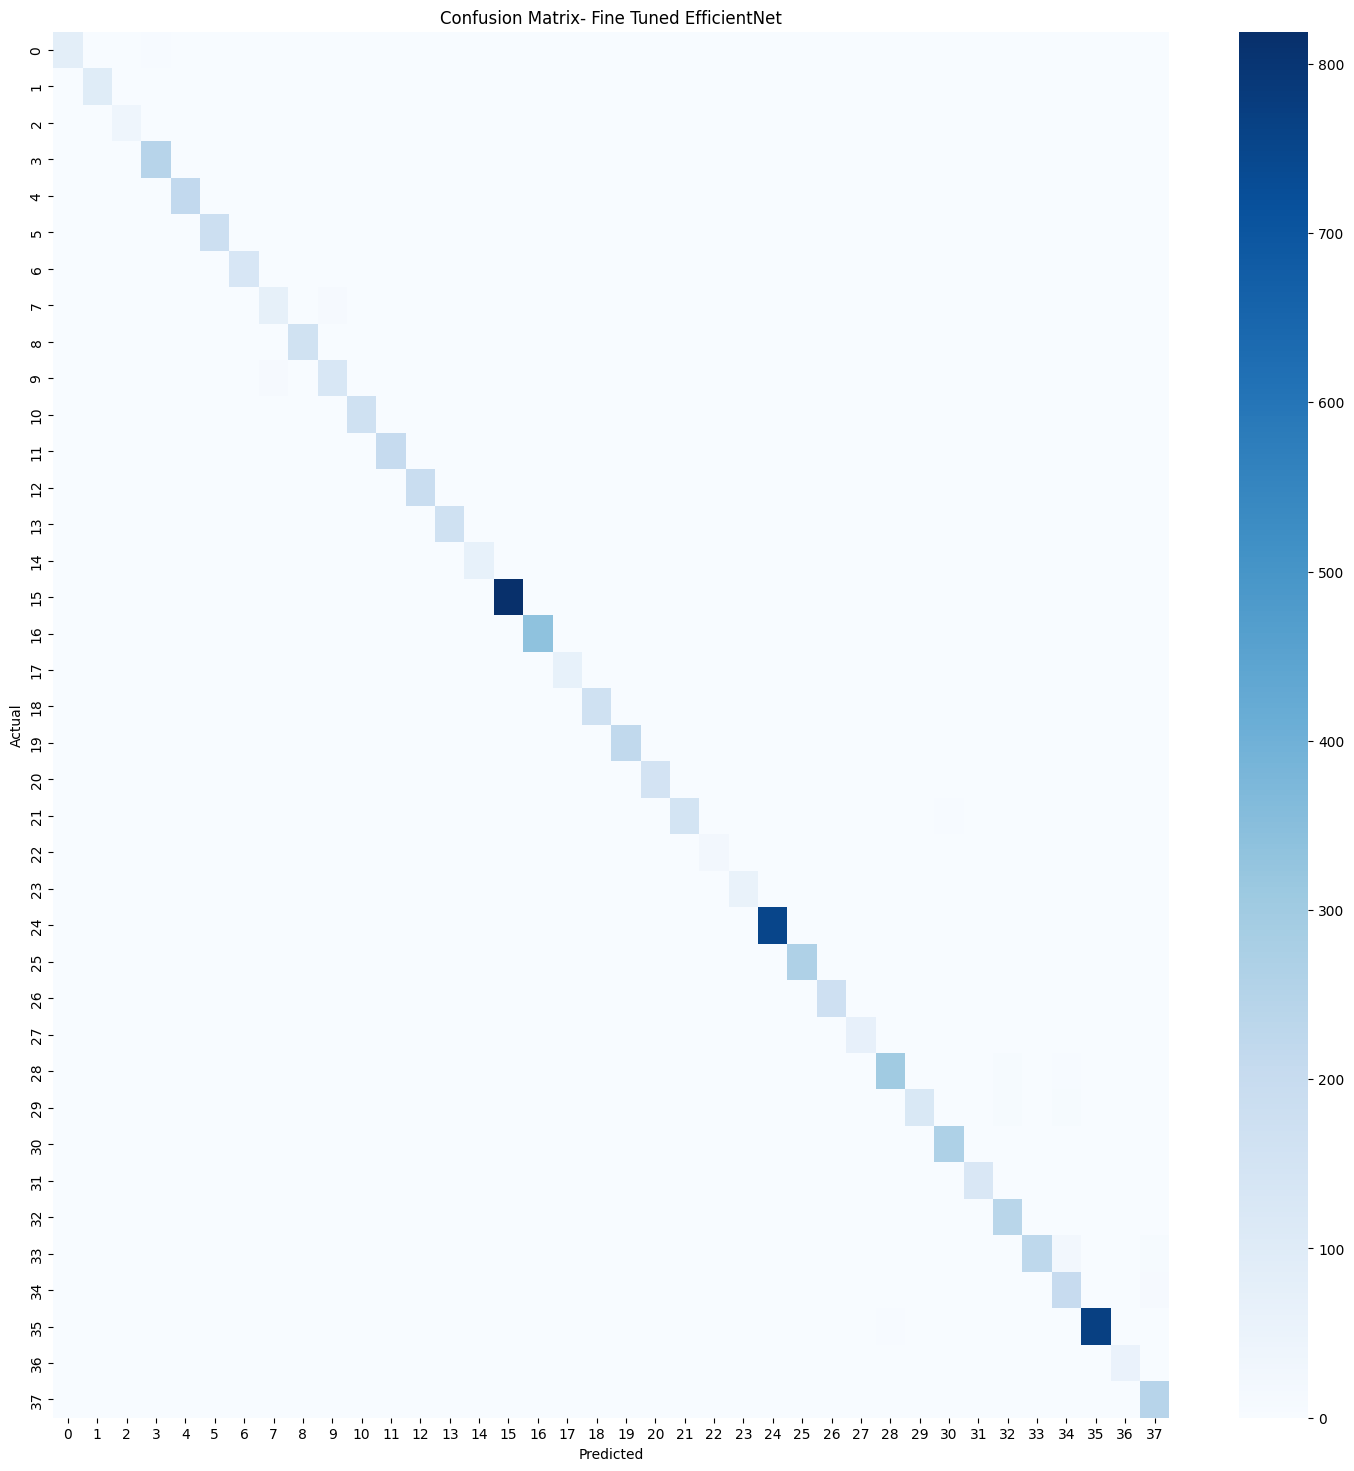

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

cm=confusion_matrix(y_true,y_pred)

plt.figure(figsize=(18,18))
sns.heatmap(cm,cmap="Blues")
plt.title("Confusion Matrix- Fine Tuned EfficientNet")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Find Hardest Classes

In [7]:
report= classification_report(y_true,y_pred,output_dict=True)

class_f1={
    cls: report[str(cls)]['f1-score']
    for cls in range(38)
}

sorted(class_f1.items(), key=lambda x: x[1])[:5]

[(7, 0.8690476190476191),
 (34, 0.8768898488120951),
 (29, 0.9070631970260223),
 (9, 0.9219858156028369),
 (33, 0.9262295081967213)]